Load CIFAR-10 using tf.keras.datasets.cifar10.load_data(). Note that these images are 32 by 32 by 3, much smaller than the photographs you will eventually use, but they have colour and have ten object classes which is similar in scale to your eventual problem.

Import Libraries

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

Load CIFAR-10 Dataset

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Training images:", x_train.shape)
print("Test images:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training images: (50000, 32, 32, 3)
Test images: (10000, 32, 32, 3)


Normalize Images

In [ ]:
x_train = x_train / 255.0
x_test = x_test / 255.0


Define Label Names

In [ ]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

Look at twenty random images with their labels. You will see that even at 32x32 the categories are recognizable: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck. The CIFAR-10 label names are documented on the Keras dataset page

Display 20 Random Images

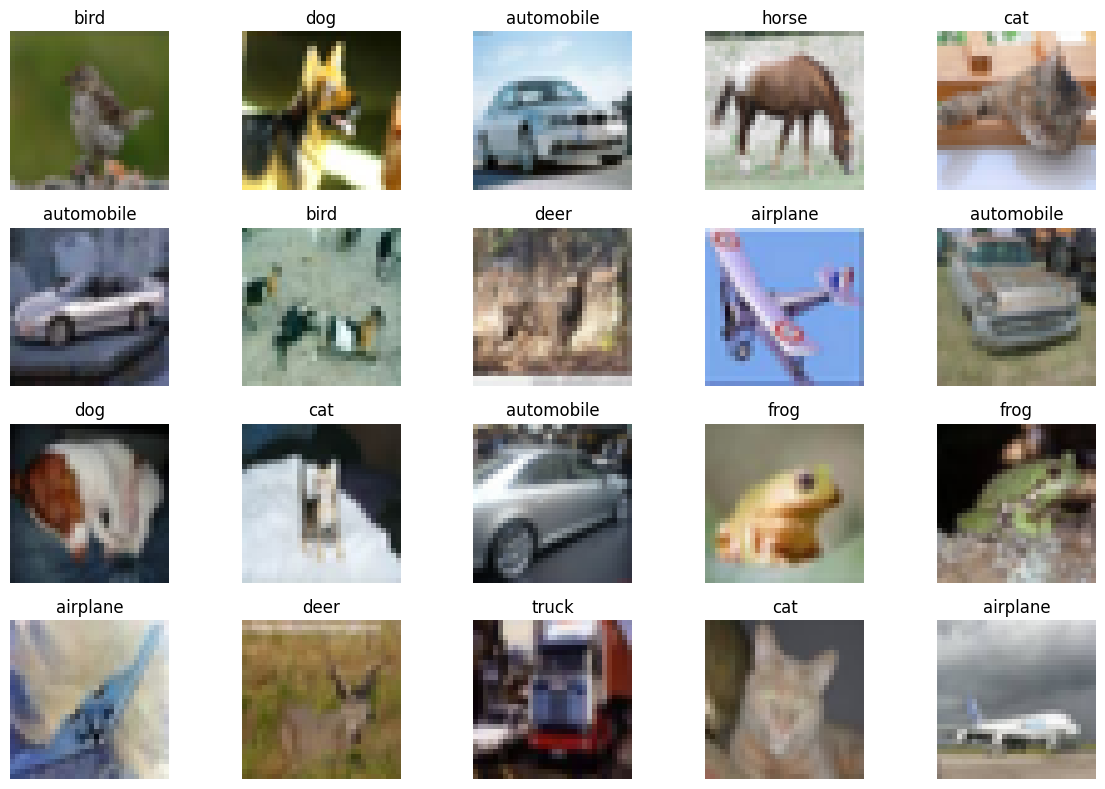

In [ ]:
plt.figure(figsize=(12,8))

for i in range(20):
    idx = np.random.randint(0, len(x_train))

    plt.subplot(4,5,i+1)
    plt.imshow(x_train[idx])
    plt.title(class_names[y_train[idx][0]])
    plt.axis('off')

plt.tight_layout()
plt.show()

Build a CNN with this structure: Conv2D(32, 3, padding=same, relu), Conv2D(32, 3, relu), MaxPooling2D(2), Conv2D(64, 3, padding=same, relu), Conv2D(64, 3, relu), MaxPooling2D(2), Flatten, Dense(128, relu), Dense(10, softmax).

In [ ]:
model = tf.keras.Sequential([

    tf.keras.layers.Conv2D(
        32,
        (3,3),
        padding='same',
        activation='relu',
        input_shape=(32,32,3)
    ),

    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation='relu'
    ),

    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(
        64,
        (3,3),
        padding='same',
        activation='relu'
    ),

    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),

    tf.keras.layers.Dense(
        10,
        activation='softmax'
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


View Model Summary

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 361,898 (1.38 MB)

 Trainable params: 361,898 (1.38 MB)

 Non-trainable params: 0 (0.00 B)

Compile with Adam at the default learning rate, sparse_categorical_crossentropy, and accuracy.

Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Train for thirty epochs with batch_size=128. This will take about ten minutes on Colab's GPU. Do not look away during the first five epochs; watch the validation accuracy.

Train for 30 Epochs

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=30,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.4147 - loss: 1.6094 - val_accuracy: 0.5219 - val_loss: 1.3558
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5684 - loss: 1.2124 - val_accuracy: 0.6106 - val_loss: 1.1138
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6462 - loss: 1.0043 - val_accuracy: 0.6308 - val_loss: 1.0627
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6995 - loss: 0.8635 - val_accuracy: 0.6830 - val_loss: 0.9131
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7366 - loss: 0.7504 - val_accuracy: 0.6981 - val_loss: 0.9036
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7656 - loss: 0.6708 - val_accuracy: 0.7287 - val_loss: 0.7876
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7953 - loss: 0.5902 - val_accuracy: 0.7419 - val_loss: 0.7624
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8187 - loss: 0.5240 - val_accur

After training, plot the training and validation accuracy curves on the same chart, and the training and validation loss curves on a second chart. The gap between training and validation, especially in the loss plot, is what overfitting looks like.

Plot Accuracy Curves

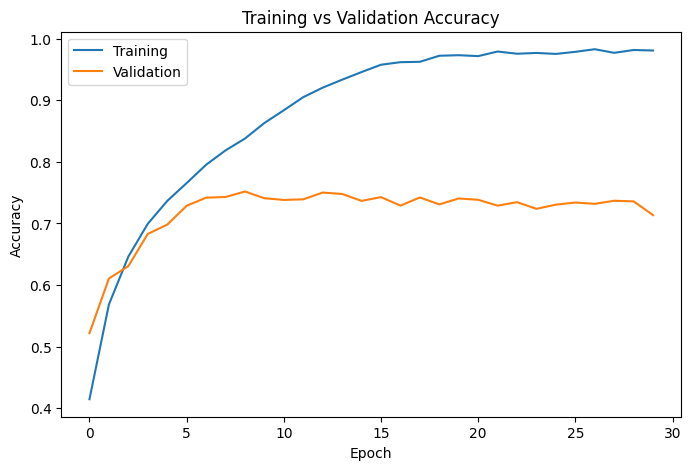

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Training",
    "Validation"
])

plt.show()

Plot Loss Curves

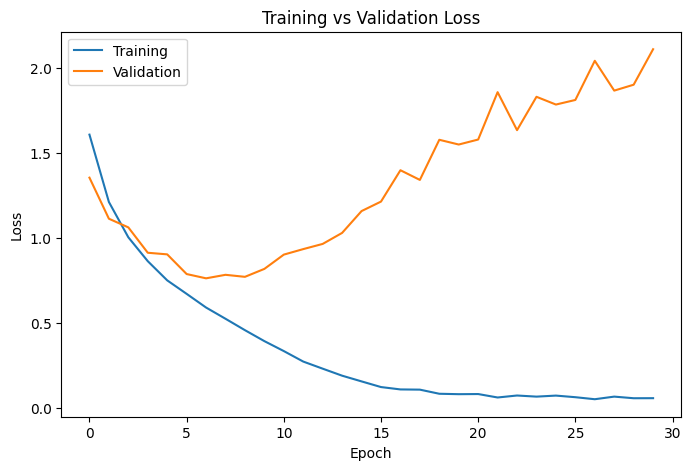

In [11]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Training",
    "Validation"
])

plt.show()

Evaluate on Test Set

In [12]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test
)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7008 - loss: 2.2254
Test Accuracy: 0.7008000016212463


The validation accuracy improved until around epoch 10 and then remained nearly constant, while training accuracy continued to increase. This indicates that the model began overfitting from approximately epoch 10 onward, memorizing the training data instead of learning patterns that generalize well to unseen images.